<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Módulo 1: Crear una Red Neuronal Artificial en TensorFlow y Pytorch</h1>
    <h3>Aprendizaje Automático Avanzado 2026</h3>
</div>



<p align="center">
  <img src="https://storage.googleapis.com/kaggle-datasets-images/2243/3791/9384af51de8baa77f6320901f53bd26b/dataset-cover.png" />
  Imagen cortesía de: https://www.kaggle.com/
</p>

## Importar las dependencias necesarias para el proyecto

In [1]:
import os

# Evita el conflicto de múltiples runtimes OpenMP (MKL + libgomp) en Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# Fijamos la semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# Nombres de las 10 clases de Fashion MNIST (el dataset trae etiquetas 0-9)
class_names = ['Camiseta/top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

In [2]:
tf.__version__

'2.21.0'

##  Pre procesado de datos



### Cargar el dataset

In [3]:
#Cargar el dataset Fashion Mnist 
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Explorar y visualizar el dataset

**Fashion MNIST** contiene 70 000 imágenes en escala de grises de $28\times28$ píxeles de prendas de ropa (60 000 para entrenamiento y 10 000 para prueba), agrupadas en 10 clases. Es un reemplazo directo del clásico MNIST de dígitos, pero un poco más desafiante. Veamos algunos ejemplos con su etiqueta.

Forma del conjunto de entrenamiento: (60000, 28, 28)
Forma del conjunto de prueba:       (10000, 28, 28)
Etiquetas (clases): [0 1 2 3 4 5 6 7 8 9]


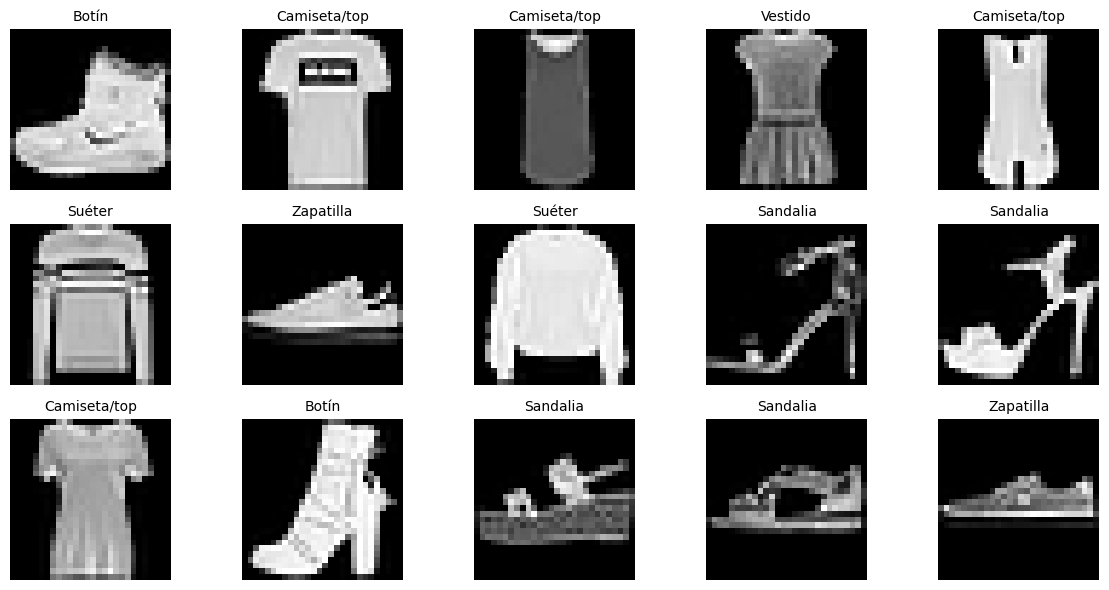

In [4]:
print("Forma del conjunto de entrenamiento:", X_train.shape)
print("Forma del conjunto de prueba:      ", X_test.shape)
print("Etiquetas (clases):", np.unique(y_train))

# Mostrar 15 prendas con su clase
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

### Normalizar las imágenes

Se divide cada imagen en los conjunto de entrenamiento y  de testing entre el valor máximo de cada uno de los píxeles (255).

De este modo, cada píxel se hallará en el rango [0, 1]. Al normalizar las imágenes, nos aseguramos que nuestro modelo de RNA entrenará más rápidamente.

In [5]:
X_train = X_train/255


In [6]:
X_test = X_test/255

In [6]:
X_train.shape

(60000, 28, 28)

### Redimensionar el dataset

Como vamos a utilizar una red neuronal totalmente conectada, vamos a redimensionar los subconjuntos de entrenamiento y testing a formato de vector en lugar de en formato de matriz.

In [7]:
#Como cada imagen tiene 28x28 píxeles, usamos la función reshape en todo el dataset de entrenamiento para convertirlo 
# en vectores de tamaño [-1 (todos los elementos), anchura * altura]
X_train = X_train.reshape(-1,28*28)
X_test = X_test.reshape(-1,28*28)

In [8]:
X_train.shape

(60000, 784)

## Construir la Red Neuronal Artificial

### Definir el modelo

Simplemente se define un objeto de modelo Sequential.

In [9]:
model = tf.keras.models.Sequential()
# Capa de entrada: vectores de 784 valores (28x28 aplanado)
model.add(tf.keras.layers.Input(shape=(784,)))

### Añadir la primera capa totalmente conectada (capa Densa)

Hiperparámetros de la capa:
- número de unidades/neuronas: 128
- función de activación: ReLU

La forma de la entrada (784,) ya quedó definida por la capa `Input` anterior.


In [10]:
model.add(tf.keras.layers.Dense(units=128, activation='relu'))

### Añadir una capa de Dropout 

Dropout es una técnica de Regularization donde aleatoriamente se asignan a ciertas neuronas de la red el valor cero. De este modo, mientras se entrena, estas neuronas no actualizarán sus valores. Al tener cierto porcentaje de neuronas sin actualizar, el proceso de entrenamiento toma más tiempo pero por contra tenemos menos posibilidades de sufrir overfitting.

In [11]:
model.add(tf.keras.layers.Dropout(0.2))

### Añadir la segunda capa (capa de salida)

- unidades: número de clases (10 en el caso del Fashion MNIST)
- función de activación: 'softmax' (probabilidades de cada clase)

In [12]:
model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

### Compilar el modelo

- Optimizer: Adam
- Loss: Sparse softmax (categorical) crossentropy 

In [13]:
# Usamos 'accuracy' como métrica de evaluación (proporción de aciertos)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrenamos durante varias **épocas** y reservamos un 10 % de los datos para **validación**. Guardamos el objeto `history` que devuelve `fit` para poder graficar después las curvas de entrenamiento.


In [15]:
history_tf = model.fit(X_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8075 - loss: 0.5395 - val_accuracy: 0.8503 - val_loss: 0.4004
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8536 - loss: 0.4049 - val_accuracy: 0.8615 - val_loss: 0.3739
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8654 - loss: 0.3687 - val_accuracy: 0.8675 - val_loss: 0.3589
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8733 - loss: 0.3446 - val_accuracy: 0.8710 - val_loss: 0.3499
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8776 - loss: 0.3304 - val_accuracy: 0.8717 - val_loss: 0.3506
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8831 - loss: 0.3170 - val_accuracy: 0.8747 - val_loss: 0.3518
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8868 - loss: 0.3040 - val_accuracy: 0.8725 - val_loss: 0.3482
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8896 - loss: 0.2960 - 

### Evaluación del modelo y predicción

In [20]:
X_test.shape

(10000, 28, 28)

In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8810 - loss: 0.3521


In [17]:
print("Test accuracy: {}".format(test_accuracy))

Test accuracy: 0.8809999823570251


### Curvas de entrenamiento (TensorFlow)

Graficamos la pérdida y la precisión de entrenamiento frente a las de validación, época a época.

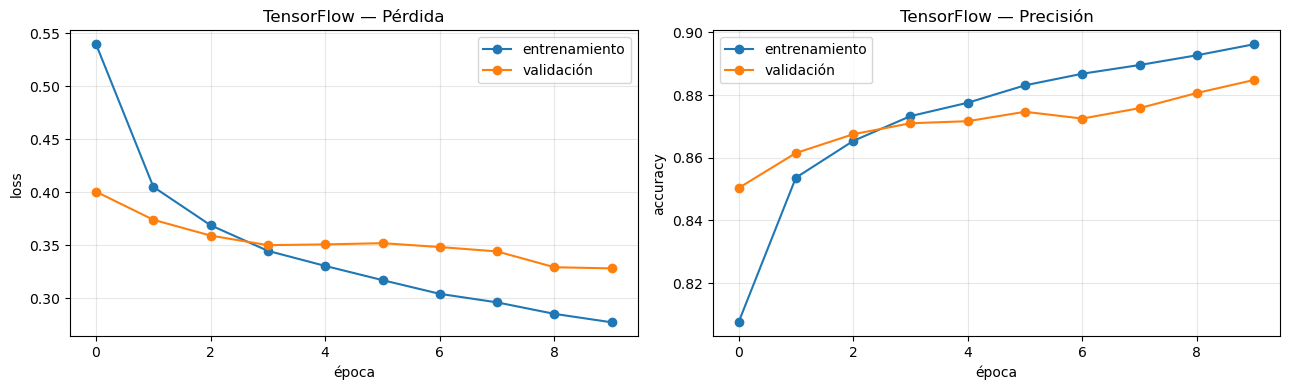

In [18]:
h = history_tf.history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(h['loss'], marker='o', label='entrenamiento')
ax1.plot(h['val_loss'], marker='o', label='validación')
ax1.set_title('TensorFlow — Pérdida'); ax1.set_xlabel('época'); ax1.set_ylabel('loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(h['accuracy'], marker='o', label='entrenamiento')
ax2.plot(h['val_accuracy'], marker='o', label='validación')
ax2.set_title('TensorFlow — Precisión'); ax2.set_xlabel('época'); ax2.set_ylabel('accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Predicciones del modelo (TensorFlow)

Mostramos 15 prendas del conjunto de prueba con la predicción del modelo. El título va en **verde** si es correcta y en **rojo** si es un error (indicando la clase real).

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


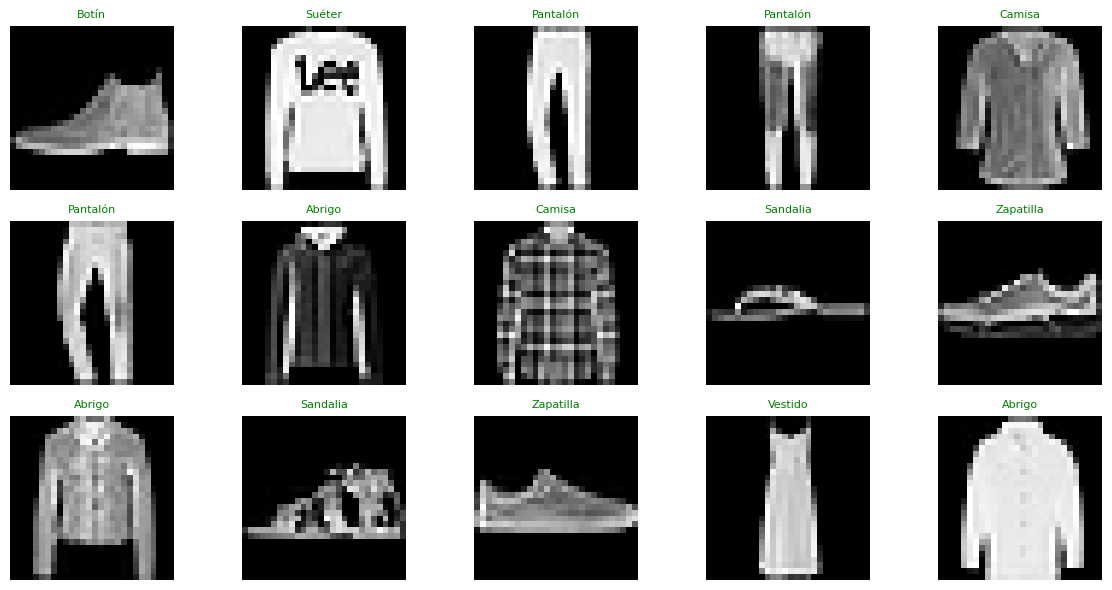

In [19]:
# Predicciones sobre el conjunto de prueba (probabilidades -> clase con argmax)
y_prob_tf = model.predict(X_test)
y_pred_tf = y_prob_tf.argmax(axis=1)

plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')   # deshacemos el aplanado solo para mostrar
    correcto = y_pred_tf[i] == y_test[i]
    color = 'green' if correcto else 'red'
    titulo = class_names[y_pred_tf[i]] if correcto else f'{class_names[y_pred_tf[i]]}\n(real: {class_names[y_test[i]]})'
    plt.title(titulo, color=color, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

### Guardar la arquitectura (topoligía) de la red neuronal

In [20]:
model_json = model.to_json()
with open('fashion_model.json', 'w') as json_file:
    json_file.write(model_json)

### Guardar los pesos de la red neuronal

In [21]:
# En Keras 3 el archivo de pesos debe terminar en '.weights.h5'
model.save_weights('fashion_model.weights.h5')

#  La misma red, ahora con PyTorch

Vamos a construir **exactamente la misma red** (784 → 128 con ReLU → Dropout 0.2 → 10) pero usando **PyTorch**, para contrastar ambos frameworks. Reutilizamos los **mismos datos** ya normalizados y aplanados, de modo que la comparación sea justa.

**Diferencias principales frente a TensorFlow/Keras que veremos:**

| | TensorFlow / Keras | PyTorch |
|---|---|---|
| Definir el modelo | `tf.keras.Sequential([...])` | `nn.Sequential(...)` o clase `nn.Module` |
| Última capa | `Dense(10, activation='softmax')` | `nn.Linear(128, 10)` → **logits** (sin softmax) |
| Pérdida | `sparse_categorical_crossentropy` | `nn.CrossEntropyLoss` (incluye softmax) |
| Entrenamiento | `model.fit(...)` (una línea) | **bucle explícito** (`zero_grad`→`forward`→`backward`→`step`) |
| Datos | arrays de NumPy directos | `TensorDataset` + `DataLoader` |


### Preparar los datos (tensores y DataLoader)

Convertimos los arreglos de NumPy a **tensores** de PyTorch y los envolvemos en un `TensorDataset`, que se itera en *mini-batches* con `DataLoader`. Separamos el mismo 10 % de validación que usó TensorFlow.

In [22]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reutilizamos los MISMOS datos ya normalizados y aplanados (vectores de 784)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# Reservamos el último 10% del entrenamiento para validación
n_val = int(0.1 * len(X_train_t))
train_ds = TensorDataset(X_train_t[:-n_val], y_train_t[:-n_val])
val_ds   = TensorDataset(X_train_t[-n_val:], y_train_t[-n_val:])
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

print("Dispositivo:", device)
print("Entrenamiento:", len(train_ds), "| Validación:", len(val_ds), "| Prueba:", len(test_ds))

Dispositivo: cpu
Entrenamiento: 54000 | Validación: 6000 | Prueba: 10000


### Definir el modelo (misma arquitectura)

Usamos `nn.Sequential` para apilar las capas. Nota clave: la capa de salida es un `nn.Linear(128, 10)` que produce **logits** (sin softmax), porque `nn.CrossEntropyLoss` aplica el softmax internamente de forma más estable.

In [23]:
model_pt = nn.Sequential(
    nn.Linear(784, 128),   # capa densa: 784 -> 128
    nn.ReLU(),             # activación
    nn.Dropout(0.2),       # regularización (20% de neuronas desactivadas)
    nn.Linear(128, 10),    # capa de salida: 128 -> 10 logits (sin softmax)
).to(device)

print(model_pt)

from torchinfo import summary
summary(model_pt, input_size=(1, 784))

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=128, out_features=10, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Linear: 1-1                            [1, 128]                  100,480
├─ReLU: 1-2                              [1, 128]                  --
├─Dropout: 1-3                           [1, 128]                  --
├─Linear: 1-4                            [1, 10]                   1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (M): 0.10
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.41
Estimated Total Size (MB): 0.41

### Pérdida, optimizador y bucle de entrenamiento

A diferencia de `model.fit()` de Keras, en PyTorch escribimos el **bucle de entrenamiento** explícitamente. Definimos una función `run_epoch` que sirve tanto para entrenar como para evaluar, y entrenamos 10 épocas guardando las métricas.

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=0.001)


def run_epoch(loader, entrenar=True):
    model_pt.train() if entrenar else model_pt.eval()
    loss_tot, aciertos, total = 0.0, 0, 0
    contexto = torch.enable_grad() if entrenar else torch.no_grad()
    with contexto:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if entrenar:
                optimizer.zero_grad()        # 1. limpiar gradientes
            logits = model_pt(xb)            # 2. forward
            loss = criterion(logits, yb)     # 3. pérdida
            if entrenar:
                loss.backward()              # 4. backward
                optimizer.step()             # 5. actualizar pesos
            loss_tot += loss.item() * xb.size(0)
            aciertos += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)
    return loss_tot / total, aciertos / total


EPOCHS = 10
hist_pt = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, entrenar=True)
    va_loss, va_acc = run_epoch(val_loader, entrenar=False)
    hist_pt['loss'].append(tr_loss); hist_pt['val_loss'].append(va_loss)
    hist_pt['acc'].append(tr_acc);   hist_pt['val_acc'].append(va_acc)
    print(f"Época {epoch:2d}/{EPOCHS} | loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

Época  1/10 | loss=0.5568 acc=0.8028 | val_loss=0.4066 val_acc=0.8555
Época  2/10 | loss=0.4100 acc=0.8520 | val_loss=0.3813 val_acc=0.8622
Época  3/10 | loss=0.3740 acc=0.8644 | val_loss=0.3718 val_acc=0.8690
Época  4/10 | loss=0.3523 acc=0.8723 | val_loss=0.3600 val_acc=0.8670
Época  5/10 | loss=0.3331 acc=0.8776 | val_loss=0.3467 val_acc=0.8717
Época  6/10 | loss=0.3211 acc=0.8818 | val_loss=0.3377 val_acc=0.8743
Época  7/10 | loss=0.3121 acc=0.8852 | val_loss=0.3373 val_acc=0.8767
Época  8/10 | loss=0.3062 acc=0.8871 | val_loss=0.3257 val_acc=0.8837
Época  9/10 | loss=0.2944 acc=0.8917 | val_loss=0.3253 val_acc=0.8843
Época 10/10 | loss=0.2877 acc=0.8926 | val_loss=0.3214 val_acc=0.8862


### Curvas de entrenamiento (PyTorch)

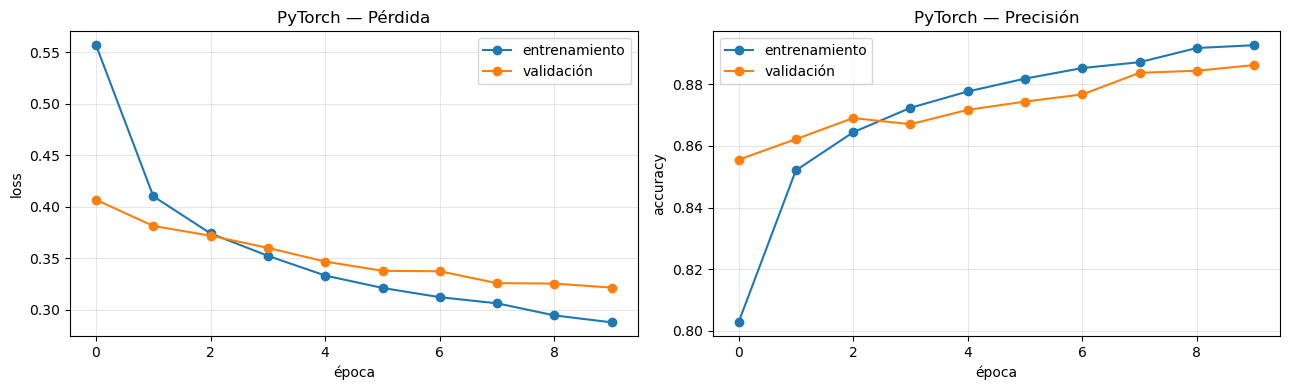

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(hist_pt['loss'], marker='o', label='entrenamiento')
ax1.plot(hist_pt['val_loss'], marker='o', label='validación')
ax1.set_title('PyTorch — Pérdida'); ax1.set_xlabel('época'); ax1.set_ylabel('loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_pt['acc'], marker='o', label='entrenamiento')
ax2.plot(hist_pt['val_acc'], marker='o', label='validación')
ax2.set_title('PyTorch — Precisión'); ax2.set_xlabel('época'); ax2.set_ylabel('accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluación y predicciones (PyTorch)

Test accuracy (PyTorch): 0.8754


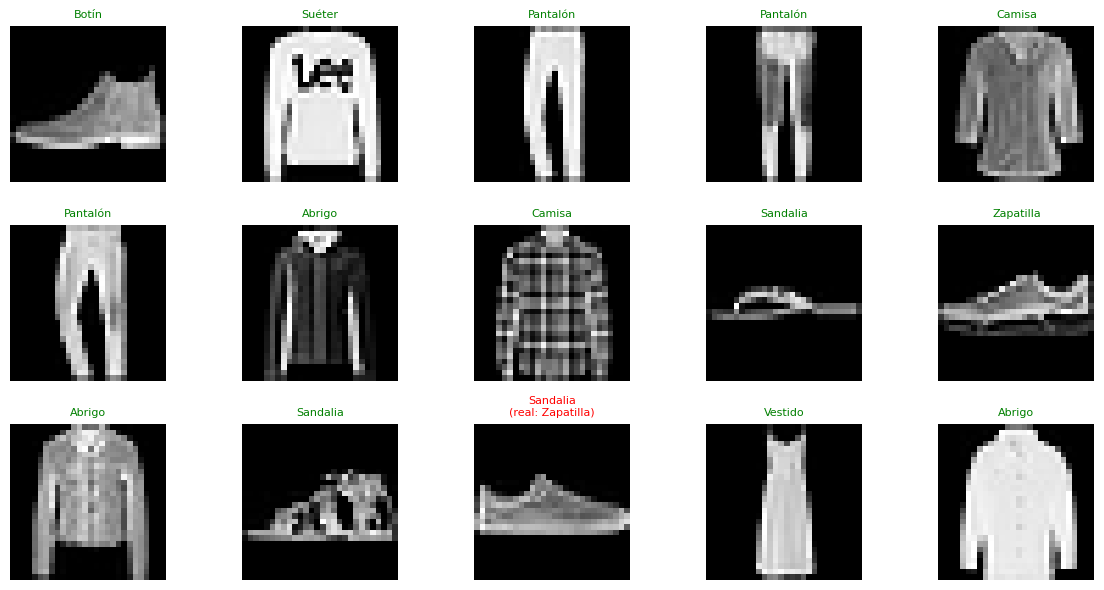

In [26]:
# Precisión en el conjunto de prueba
pt_test_loss, pt_test_acc = run_epoch(test_loader, entrenar=False)
print(f"Test accuracy (PyTorch): {pt_test_acc:.4f}")

# Predicciones sobre las primeras 15 imágenes de prueba
model_pt.eval()
with torch.no_grad():
    logits = model_pt(X_test_t[:15].to(device))
    preds_pt = logits.argmax(1).cpu().numpy()

plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    correcto = preds_pt[i] == y_test[i]
    color = 'green' if correcto else 'red'
    titulo = class_names[preds_pt[i]] if correcto else f'{class_names[preds_pt[i]]}\n(real: {class_names[y_test[i]]})'
    plt.title(titulo, color=color, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

#  Comparación de las dos implementaciones

Construimos **la misma red** (misma arquitectura, mismos datos, mismo optimizador Adam y mismas 10 épocas) en ambos frameworks. Veamos las diferencias de código lado a lado y comparemos resultados.

### Diferencias de código

**1. Definir el modelo**

```python
# TensorFlow / Keras                          # PyTorch
model = tf.keras.Sequential([                 model_pt = nn.Sequential(
    tf.keras.layers.Input(shape=(784,)),          nn.Linear(784, 128),
    tf.keras.layers.Dense(128, 'relu'),           nn.ReLU(),
    tf.keras.layers.Dropout(0.2),                 nn.Dropout(0.2),
    tf.keras.layers.Dense(10, 'softmax'),         nn.Linear(128, 10),   # logits
])                                            )
```

**2. Compilar / definir pérdida y optimizador**

```python
# TensorFlow                                  # PyTorch
model.compile(                                criterion = nn.CrossEntropyLoss()
    optimizer='adam',                         optimizer = torch.optim.Adam(
    loss='sparse_categorical_crossentropy',       model_pt.parameters(), lr=0.001)
    metrics=['accuracy'])
```

**3. Entrenar**

```python
# TensorFlow: una sola línea                  # PyTorch: bucle explícito
model.fit(X_train, y_train,                   for epoch in range(EPOCHS):
          epochs=10,                              for xb, yb in train_loader:
          validation_split=0.1)                       optimizer.zero_grad()
                                                      loss = criterion(model_pt(xb), yb)
                                                      loss.backward()
                                                      optimizer.step()
```


### Comparación de resultados

Comparamos la precisión en el conjunto de prueba de ambos modelos. Al usar la misma arquitectura y datos, los resultados deben ser muy parecidos (pequeñas diferencias se deben a la inicialización aleatoria y al orden de los *batches*).

In [27]:
import pandas as pd

comparacion = pd.DataFrame({
    'Framework': ['TensorFlow / Keras', 'PyTorch'],
    'Accuracy (test)': [round(float(test_accuracy), 4), round(float(pt_test_acc), 4)],
})
comparacion

,Framework,Accuracy (test)
0,TensorFlow / Keras,0.8810
1,PyTorch,0.8754


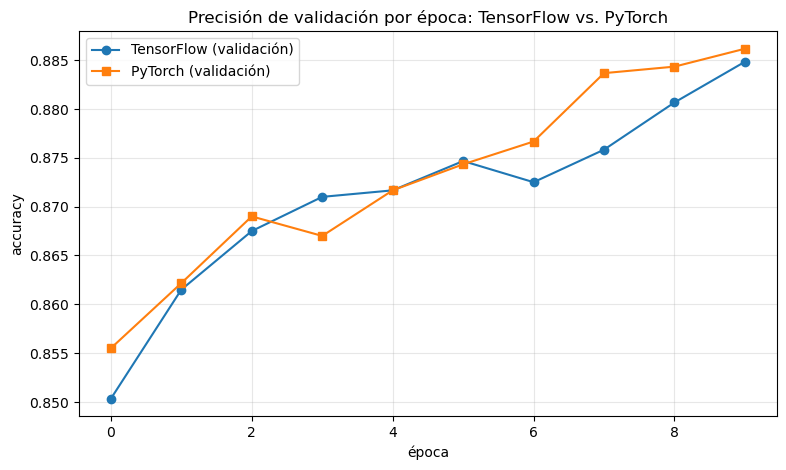

In [28]:
# Comparar las curvas de precisión de validación de ambos frameworks
plt.figure(figsize=(9, 5))
plt.plot(history_tf.history['val_accuracy'], marker='o', label='TensorFlow (validación)')
plt.plot(hist_pt['val_acc'], marker='s', label='PyTorch (validación)')
plt.title('Precisión de validación por época: TensorFlow vs. PyTorch')
plt.xlabel('época'); plt.ylabel('accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.show()


- **TensorFlow / Keras**: ideal para **prototipar rápido**, para principiantes y para **producción** con el ecosistema de Google. Menos código para tareas estándar.
- **PyTorch**: preferido en **investigación** y cuando se necesita **máximo control** sobre el entrenamiento (arquitecturas personalizadas, bucles complejos, depuración detallada). Es el estándar de facto en el ámbito académico.

**Conclusión:** ambos frameworks alcanzan prácticamente la **misma precisión** en este problema, porque la arquitectura y los datos son idénticos. La elección depende más del **flujo de trabajo, la legibilidad y el ecosistema** que del rendimiento del modelo en sí.
